   CustomerID  Age  AnnualIncome  SpendingScore
0           1   56           111              9
1           2   46            79             88
2           3   32            90              1
3           4   60            63              8
4           5   25            27             88


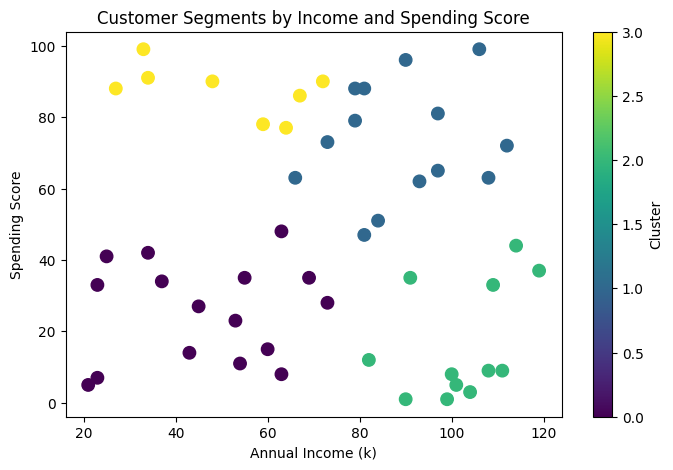

               Age  AnnualIncome  SpendingScore
Cluster                                        
0        39.687500     46.312500      25.375000
1        36.428571     89.000000      73.357143
2        46.333333    102.333333      16.416667
3        38.250000     50.500000      87.375000


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Create a small sample customer dataset
np.random.seed(42)
data = {
    'CustomerID': range(1, 51),
    'Age': np.random.randint(18, 65, 50),
    'AnnualIncome': np.random.randint(20, 120, 50),      # in thousands
    'SpendingScore': np.random.randint(1, 100, 50)        # 1-100 scale
}
customers = pd.DataFrame(data)
print(customers.head())

# Pick features to cluster on
X = customers[['AnnualIncome', 'SpendingScore']]

# Run K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customers['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8,5))
plt.scatter(customers['AnnualIncome'], customers['SpendingScore'],
            c=customers['Cluster'], cmap='viridis', s=80)
plt.title('Customer Segments by Income and Spending Score')
plt.xlabel('Annual Income (k)')
plt.ylabel('Spending Score')
plt.colorbar(label='Cluster')
plt.show()

# Summarize each cluster
print(customers.groupby('Cluster')[['Age', 'AnnualIncome', 'SpendingScore']].mean())